In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# Install required libraries (run this first in Kaggle)
!pip install pennylane torchinfo -q

# ================= IMPORTS =================
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import timedelta

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

from sklearn.metrics import *
from tqdm.auto import tqdm

# Quantum + model summary
import pennylane as qml
from torchinfo import summary

# Precision settings
np.set_printoptions(precision=3)
torch.set_printoptions(precision=3)

print("✅ All libraries imported successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 59.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 103.5 MB/s eta 0:00:0000:0100:01
✅ All libraries imported successfully!


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 6  
EPOCHS = 15
LR = 0.00005     
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
CSV_PATH = "/kaggle/input/datasets/farjanakabirsamanta/skin-cancer-dataset/HAM10000_metadata.csv"
IMG_DIR = "/kaggle/input/datasets/farjanakabirsamanta/skin-cancer-dataset/Skin Cancer/Skin Cancer"

In [6]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [7]:
class SkinCancerDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.df['dx'].unique())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.df['label'] = self.df['dx'].map(self.class_to_idx)

        self.image_paths, self.labels = [], []

        for _, row in self.df.iterrows():
            path = os.path.join(self.img_dir, row['image_id'] + ".jpg")
            if os.path.exists(path):
                self.image_paths.append(path)
                self.labels.append(row['label'])

        print(f"Total images: {len(self.image_paths)}")

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [8]:
full_dataset = SkinCancerDataset(CSV_PATH, IMG_DIR, transform)

CLASSES = full_dataset.classes
num_classes = len(CLASSES)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

Total images: 10015


In [9]:
import pennylane as qml
import torch
import torch.nn as nn

n_qubits = 4
n_layers = 2

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):

    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    for l in range(n_layers):
        for i in range(n_qubits):
            qml.RX(weights[l, i], wires=i)
            qml.RZ(weights[l, i], wires=i)

        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[n_qubits-1, 0])

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


class QuantumLayer(nn.Module):
    def __init__(self, n_qubits=4):
        super().__init__()
        self.n_qubits = n_qubits

        self.weights = nn.Parameter(
            0.01 * torch.randn(n_layers, n_qubits)
        )

    def forward(self, x):
        outputs = []

        for i in range(x.shape[0]):
            q_in = x[i]
            out = quantum_circuit(q_in, self.weights)
            out = torch.stack(out).to(torch.float32)
            outputs.append(out)

        return torch.stack(outputs)

In [10]:
class HybridMobileNet(nn.Module):
    def __init__(self, num_classes, n_qubits=4):
        super().__init__()

        base = models.mobilenet_v2(weights="DEFAULT")
        self.features = base.features

        freeze_layers = len(self.features)//2
        for i in range(freeze_layers):
            for p in self.features[i].parameters():
                p.requires_grad = False

        self.q_branch = nn.Sequential(
            nn.Conv2d(160, 40, 1),
            nn.BatchNorm2d(40),
            nn.ReLU(),

            nn.Conv2d(40, 8, 3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.q_fc = nn.Linear(8, n_qubits)
        self.quantum = QuantumLayer(n_qubits)

        self.extra = nn.Sequential(
            nn.Conv2d(1280,128,1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128,96,3,padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU()
        )

        self.final_fc = nn.Linear(96 + n_qubits, num_classes)

    def forward(self,x):
        x = self.features[:17](x)

        q = self.q_branch(x)
        q = torch.flatten(q,1)
        q = torch.tanh(self.q_fc(q))
        q = self.quantum(q)

        c = self.features[17:](x)
        c = self.extra(c)
        c = nn.functional.adaptive_avg_pool2d(c,(1,1))
        c = torch.flatten(c,1)

        out = torch.cat([c,q],dim=1)
        return self.final_fc(out)

In [11]:
model = HybridMobileNet(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 120MB/s]


In [12]:
def custom_metrics(y_pred, y_true, loss):
    y_pred = torch.argmax(y_pred,1)

    y_true = y_true.cpu().numpy()
    y_pred = y_pred.cpu().numpy()

    return {
        "loss": round(loss,3),
        "accuracy": round(accuracy_score(y_true,y_pred),3)
    }

In [13]:
train_hist = {"loss":[],"accuracy":[]}
val_hist = {"loss":[],"accuracy":[]}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    model.train()
    train_loss=0
    preds, labels = [],[]

    for x,y in tqdm(train_loader):
        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds.append(out)
        labels.append(y)

    preds = torch.cat(preds)
    labels = torch.cat(labels)

    train_metrics = custom_metrics(preds,labels,train_loss/len(train_loader))
    train_hist["loss"].append(train_metrics["loss"])
    train_hist["accuracy"].append(train_metrics["accuracy"])

    print("Train:", {k:f"{v:.3f}" for k,v in train_metrics.items()})

    model.eval()
    val_loss=0
    preds, labels = [],[]

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out,y)

            val_loss += loss.item()
            preds.append(out)
            labels.append(y)

    preds = torch.cat(preds)
    labels = torch.cat(labels)

    val_metrics = custom_metrics(preds,labels,val_loss/len(val_loader))
    val_hist["loss"].append(val_metrics["loss"])
    val_hist["accuracy"].append(val_metrics["accuracy"])

    print("Val:", {k:f"{v:.3f}" for k,v in val_metrics.items()})


Epoch 1/15


  0%|          | 0/1169 [00:00<?, ?it/s]

Train: {'loss': '1.114', 'accuracy': '0.657'}
Val: {'loss': '0.653', 'accuracy': '0.782'}

Epoch 2/15


  0%|          | 0/1169 [00:00<?, ?it/s]

Train: {'loss': '0.750', 'accuracy': '0.749'}
Val: {'loss': '0.568', 'accuracy': '0.811'}

Epoch 3/15


...

Train: {'loss': '0.162', 'accuracy': '0.954'}
Val: {'loss': '0.547', 'accuracy': '0.830'}

Epoch 14/15


  0%|          | 0/1169 [00:00<?, ?it/s]

Train: {'loss': '0.140', 'accuracy': '0.960'}
Val: {'loss': '0.523', 'accuracy': '0.836'}

Epoch 15/15


  0%|          | 0/1169 [00:00<?, ?it/s]

Train: {'loss': '0.127', 'accuracy': '0.968'}
Val: {'loss': '0.571', 'accuracy': '0.840'}


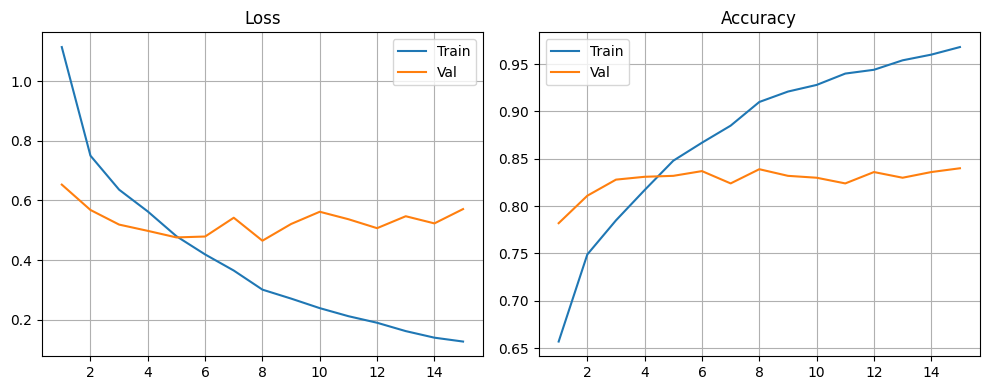

In [14]:
epochs = range(1,len(train_hist["loss"])+1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(epochs,train_hist["loss"],label="Train")
plt.plot(epochs,val_hist["loss"],label="Val")
plt.title("Loss")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(epochs,train_hist["accuracy"],label="Train")
plt.plot(epochs,val_hist["accuracy"],label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [15]:
model.eval()
test_loss = 0
preds, labels = [], []

with torch.no_grad():
    for x,y in test_loader:
        x,y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out,y)

        test_loss += loss.item()
        preds.append(out)
        labels.append(y)

preds = torch.cat(preds)
labels = torch.cat(labels)

test_metrics = custom_metrics(preds, labels, test_loss/len(test_loader))

print("Test Results:", test_metrics)

Test Results: {'loss': 0.599, 'accuracy': 0.823}


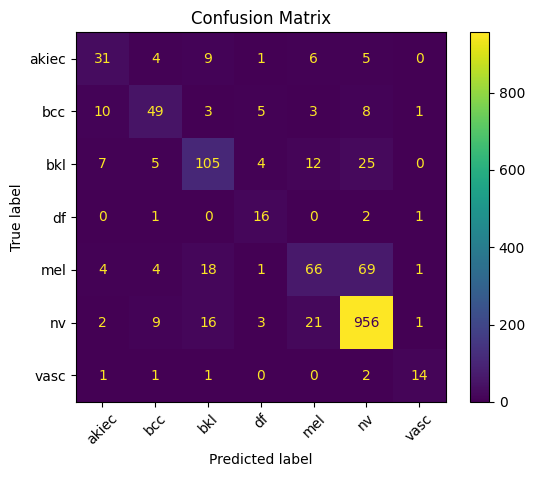

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = labels.cpu().numpy()
y_pred = torch.argmax(preds,1).cpu().numpy()

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3))

              precision    recall  f1-score   support

       akiec      0.564     0.554     0.559        56
         bcc      0.671     0.620     0.645        79
         bkl      0.691     0.665     0.677       158
          df      0.533     0.800     0.640        20
         mel      0.611     0.405     0.487       163
          nv      0.896     0.948     0.921      1008
        vasc      0.778     0.737     0.757        19

    accuracy                          0.823      1503
   macro avg      0.678     0.676     0.669      1503
weighted avg      0.813     0.823     0.815      1503



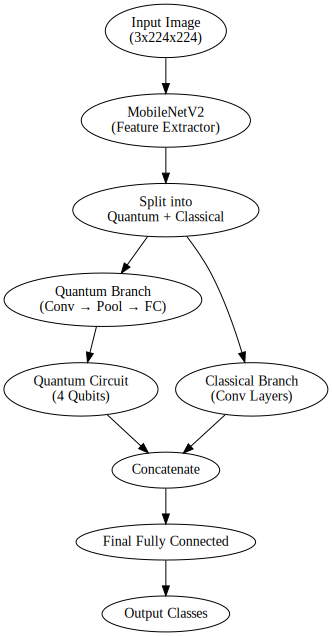

In [22]:
from graphviz import Digraph

dot = Digraph()

dot.node('Input', 'Input Image\n(3x224x224)')
dot.node('CNN', 'MobileNetV2\n(Feature Extractor)')
dot.node('Split', 'Split into\nQuantum + Classical')

dot.node('QBranch', 'Quantum Branch\n(Conv → Pool → FC)')
dot.node('QCircuit', 'Quantum Circuit\n(4 Qubits)')

dot.node('CBranch', 'Classical Branch\n(Conv Layers)')

dot.node('Concat', 'Concatenate')
dot.node('FC', 'Final Fully Connected')
dot.node('Output', 'Output Classes')

dot.edges([
    ('Input','CNN'),
    ('CNN','Split'),
    ('Split','QBranch'),
    ('QBranch','QCircuit'),
    ('Split','CBranch'),
    ('QCircuit','Concat'),
    ('CBranch','Concat'),
    ('Concat','FC'),
    ('FC','Output')
])

dot

In [23]:
summary(model, input_size=(1,3,224,224))

Layer (type:depth-idx)                             Output Shape              Param #
HybridMobileNet                                    [1, 7]                    --
├─Sequential: 1-5                                  --                        (recursive)
│    └─Conv2dNormActivation: 2-1                   [1, 32, 112, 112]         --
│    │    └─Conv2d: 3-1                            [1, 32, 112, 112]         (864)
│    │    └─BatchNorm2d: 3-2                       [1, 32, 112, 112]         (64)
│    │    └─ReLU6: 3-3                             [1, 32, 112, 112]         --
│    └─InvertedResidual: 2-2                       [1, 16, 112, 112]         --
│    │    └─Sequential: 3-4                        [1, 16, 112, 112]         (896)
│    └─InvertedResidual: 2-3                       [1, 24, 56, 56]           --
│    │    └─Sequential: 3-5                        [1, 24, 56, 56]           (5,136)
│    └─InvertedResidual: 2-4                       [1, 24, 56, 56]           --
│    │    └─S

In [24]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total: {total_params}")
print(f"Trainable: {trainable_params}")

Total: 2509151
Trainable: 2378335
